# Loading the Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [2]:
import pandas as pd

In [4]:
data = "/content/drive/MyDrive/IAPC Project/Spectrogram Dataset/spectrogram_dataset_encoded.csv"
df = pd.read_csv(data)

In [5]:
df.head()

,file_path,label,language,label_encoded,language_encoded
0,/content/drive/MyDrive/IAPC Project/Spectrogra...,AI,English,0,0
1,/content/drive/MyDrive/IAPC Project/Spectrogra...,AI,English,0,0
2,/content/drive/MyDrive/IAPC Project/Spectrogra...,AI,English,0,0
3,/content/drive/MyDrive/IAPC Project/Spectrogra...,AI,English,0,0
4,/content/drive/MyDrive/IAPC Project/Spectrogra...,AI,English,0,0


# Dataset Uploadation

In [6]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

In [7]:
df = df[["file_path", "label_encoded", "language_encoded"]]

print(df.head())

                                           file_path  label_encoded  \
0  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   
1  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   
2  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   
3  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   
4  /content/drive/MyDrive/IAPC Project/Spectrogra...              0   

   language_encoded  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  


In [8]:
df_eng = df[df["language_encoded"] == 0].reset_index(drop=True)

df_hin = df[df["language_encoded"] == 1].reset_index(drop=True)

print("English samples:", len(df_eng))
print("Hindi samples:", len(df_hin))

English samples: 706
Hindi samples: 992


In [9]:
class SpectrogramDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "file_path"]
        label = self.df.loc[idx, "label_encoded"]

        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [10]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [11]:
dataset_eng = SpectrogramDataset(df_eng, transform=transform)

dataset_hin = SpectrogramDataset(df_hin, transform=transform)

In [12]:
from sklearn.model_selection import train_test_split

train_eng, val_eng = train_test_split(df_eng, test_size=0.2, random_state=42)
train_hin, val_hin = train_test_split(df_hin, test_size=0.2, random_state=42)

train_eng = train_eng.reset_index(drop=True)
val_eng = val_eng.reset_index(drop=True)

train_hin = train_hin.reset_index(drop=True)
val_hin = val_hin.reset_index(drop=True)

train_dataset_eng = SpectrogramDataset(train_eng, transform)
val_dataset_eng   = SpectrogramDataset(val_eng, transform)

train_dataset_hin = SpectrogramDataset(train_hin, transform)
val_dataset_hin   = SpectrogramDataset(val_hin, transform)

In [13]:
batch_size = 32

train_loader_eng = DataLoader(train_dataset_eng, batch_size=batch_size, shuffle=True)
val_loader_eng   = DataLoader(val_dataset_eng, batch_size=batch_size, shuffle=False)

train_loader_hin = DataLoader(train_dataset_hin, batch_size=batch_size, shuffle=True)
val_loader_hin   = DataLoader(val_dataset_hin, batch_size=batch_size, shuffle=False)

# Training

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [15]:
class VoiceCNN(nn.Module):
    def __init__(self):
        super(VoiceCNN, self).__init__()

        # 🔹 Convolutional Layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)

        # 🔹 Fully Connected Layers
        self.fc1 = nn.Linear(256 * 8 * 8, 256)   # adjust if image size changes
        self.dropout = nn.Dropout(0.3)

        self.fc2 = nn.Linear(256, 128)

        self.fc3 = nn.Linear(128, 1)    # Output layer

    def forward(self, x, return_features=False):

        # 🔹 Conv Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # 🔹 Conv Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # 🔹 Conv Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # 🔹 Conv Block 4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        # 🔹 Flatten
        x = x.view(x.size(0), -1)

        # 🔹 Dense Layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        features = F.relu(self.fc2(x))

        output = torch.sigmoid(self.fc3(features))

        if return_features:
            return features

        return output

In [16]:
model_eng = VoiceCNN()

criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model_eng.parameters(), lr=0.0001)

In [17]:
num_epochs = 20

for epoch in range(num_epochs):
    model_eng.train()

    running_loss = 0.0

    for images, labels in train_loader_eng:

        # Forward pass
        outputs = model_eng(images).squeeze()

        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/20], Loss: 9.6609
Epoch [2/20], Loss: 5.3930
Epoch [3/20], Loss: 3.3854
Epoch [4/20], Loss: 1.6772
Epoch [5/20], Loss: 0.9061
Epoch [6/20], Loss: 0.5278
Epoch [7/20], Loss: 0.3209
Epoch [8/20], Loss: 0.2649
Epoch [9/20], Loss: 0.1550
Epoch [10/20], Loss: 0.1556
Epoch [11/20], Loss: 0.2086
Epoch [12/20], Loss: 0.1583
Epoch [13/20], Loss: 0.1537
Epoch [14/20], Loss: 0.0493
Epoch [15/20], Loss: 0.0480
Epoch [16/20], Loss: 0.0399
Epoch [17/20], Loss: 0.0256
Epoch [18/20], Loss: 0.0251
Epoch [19/20], Loss: 0.0151
Epoch [20/20], Loss: 0.0138


In [18]:
model_eng.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader_eng:

        outputs = model_eng(images).squeeze()
        preds = (outputs > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Validation Accuracy:", accuracy)

Validation Accuracy: 1.0


In [19]:
model_hin = VoiceCNN()

num_epochs = 20

for epoch in range(num_epochs):
    model_hin.train()

    running_loss = 0.0

    for images, labels in train_loader_hin:

        # Forward pass
        outputs = model_hin(images).squeeze()

        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/20], Loss: 17.7107
Epoch [2/20], Loss: 17.6562
Epoch [3/20], Loss: 17.7147
Epoch [4/20], Loss: 17.7019
Epoch [5/20], Loss: 17.7016
Epoch [6/20], Loss: 17.6306
Epoch [7/20], Loss: 17.6638
Epoch [8/20], Loss: 17.6514
Epoch [9/20], Loss: 17.6542
Epoch [10/20], Loss: 17.6898
Epoch [11/20], Loss: 17.6988
Epoch [12/20], Loss: 17.7468
Epoch [13/20], Loss: 17.6997
Epoch [14/20], Loss: 17.6757
Epoch [15/20], Loss: 17.7076
Epoch [16/20], Loss: 17.6333
Epoch [17/20], Loss: 17.6767
Epoch [18/20], Loss: 17.6732
Epoch [19/20], Loss: 17.6462
Epoch [20/20], Loss: 17.6779


In [20]:
model_hin.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader_hin:

        outputs = model_hin(images).squeeze()
        preds = (outputs > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.36180904522613067


In [21]:
model_eng.eval()
model_hin.eval()

VoiceCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)

In [22]:
def extract_features(model, dataloader):
    features_list = []
    labels_list = []

    model.eval()

    with torch.no_grad():
        for images, labels in dataloader:

            outputs = model(images, return_features=True)

            features_list.append(outputs.cpu())
            labels_list.append(labels.cpu())

    features = torch.cat(features_list)
    labels = torch.cat(labels_list)

    return features, labels

In [23]:
features_eng, labels_eng = extract_features(model_eng, val_loader_eng)

In [24]:
features_hin, labels_hin = extract_features(model_hin, val_loader_hin)

In [25]:
features_eng = features_eng.numpy()
labels_eng = labels_eng.numpy()

features_hin = features_hin.numpy()
labels_hin = labels_hin.numpy()

In [26]:
ai_eng = features_eng[labels_eng == 0]
human_eng = features_eng[labels_eng == 1]

ai_hin = features_hin[labels_hin == 0]
human_hin = features_hin[labels_hin == 1]

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [28]:
sim_eng = cosine_similarity(ai_eng, human_eng)
sim_hin = cosine_similarity(ai_hin, human_hin)

print("English AI-Human similarity:", np.mean(sim_eng))
print("Hindi AI-Human similarity:", np.mean(sim_hin))

English AI-Human similarity: 0.29561123
Hindi AI-Human similarity: 0.6904348


# Internal Comparisons

In [29]:
sim_human_eng = cosine_similarity(human_eng, human_eng)

sim_ai_eng = cosine_similarity(ai_eng, ai_eng)

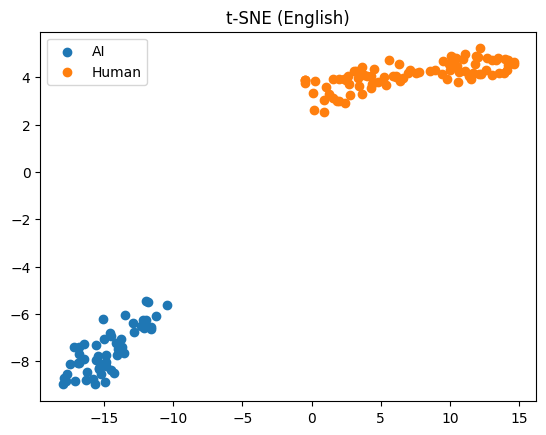

In [30]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2)

reduced = tsne.fit_transform(features_eng)

plt.scatter(reduced[labels_eng==0,0], reduced[labels_eng==0,1], label="AI")
plt.scatter(reduced[labels_eng==1,0], reduced[labels_eng==1,1], label="Human")
plt.legend()
plt.title("t-SNE (English)")
plt.show()

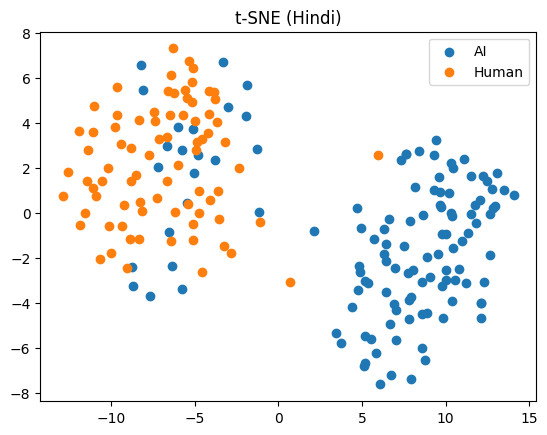

In [31]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2)

reduced = tsne.fit_transform(features_hin)

plt.scatter(reduced[labels_hin==0,0], reduced[labels_hin==0,1], label="AI")
plt.scatter(reduced[labels_hin==1,0], reduced[labels_hin==1,1], label="Human")
plt.legend()
plt.title("t-SNE (Hindi)")
plt.show()

In [32]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def paired_similarity(A, B):
    n = min(len(A), len(B))
    sims = []
    for i in range(n):
        sims.append(
            cosine_similarity(A[i].reshape(1,-1),
                              B[i].reshape(1,-1))[0,0]
        )
    return np.array(sims)

def within_similarity(X, k=200):
    # sample k pairs to avoid O(N^2)
    idx = np.random.choice(len(X), size=min(k, len(X)), replace=False)
    sims = []
    for i in idx:
        j = np.random.randint(0, len(X))
        sims.append(cosine_similarity(X[i].reshape(1,-1),
                                      X[j].reshape(1,-1))[0,0])
    return np.array(sims)

# English
sim_e_ah = paired_similarity(ai_eng, human_eng)
sim_e_aa = within_similarity(ai_eng)
sim_e_hh = within_similarity(human_eng)

# Hindi
sim_h_ah = paired_similarity(ai_hin, human_hin)
sim_h_aa = within_similarity(ai_hin)
sim_h_hh = within_similarity(human_hin)

print("English:", sim_e_ah.mean(), sim_e_aa.mean(), sim_e_hh.mean())
print("Hindi:",   sim_h_ah.mean(), sim_h_aa.mean(), sim_h_hh.mean())

English: 0.2896998 0.9897177 0.98799735
Hindi: 0.6943931 0.7927458 0.76518947


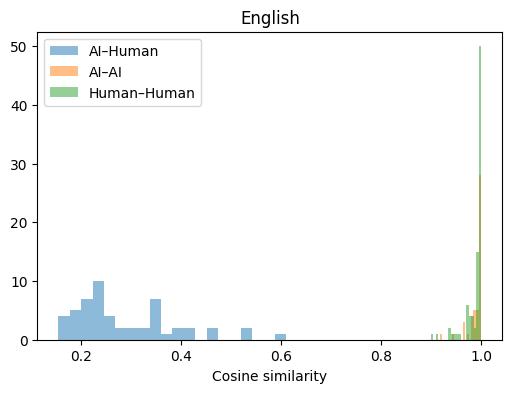

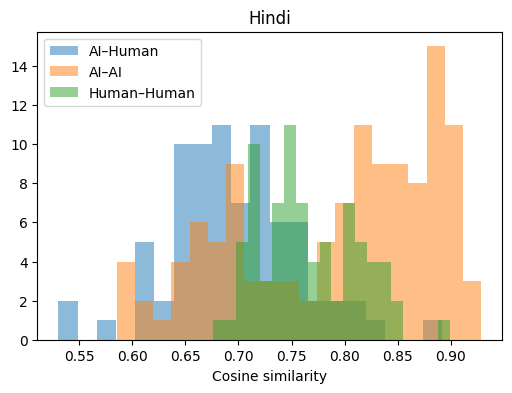

In [33]:
import matplotlib.pyplot as plt

def plot_hist(title, ah, aa, hh):
    plt.figure(figsize=(6,4))
    plt.hist(ah, bins=20, alpha=0.5, label="AI–Human")
    plt.hist(aa, bins=20, alpha=0.5, label="AI–AI")
    plt.hist(hh, bins=20, alpha=0.5, label="Human–Human")
    plt.legend(); plt.title(title); plt.xlabel("Cosine similarity"); plt.show()

plot_hist("English", sim_e_ah, sim_e_aa, sim_e_hh)
plot_hist("Hindi",   sim_h_ah, sim_h_aa, sim_h_hh)

In [34]:
from sklearn.metrics import silhouette_score

X_eng = np.vstack([ai_eng, human_eng])
y_eng = np.array([0]*len(ai_eng) + [1]*len(human_eng))

X_hin = np.vstack([ai_hin, human_hin])
y_hin = np.array([0]*len(ai_hin) + [1]*len(human_hin))

print("Silhouette (English):", silhouette_score(X_eng, y_eng))
print("Silhouette (Hindi):",   silhouette_score(X_hin, y_hin))

Silhouette (English): 0.7662203
Silhouette (Hindi): 0.22307628


In [35]:
diff_eng = np.abs(ai_eng.mean(axis=0) - human_eng.mean(axis=0))
diff_hin = np.abs(ai_hin.mean(axis=0) - human_hin.mean(axis=0))

# top-k dimensions that differ most
k = 10
top_eng = np.argsort(diff_eng)[-k:]
top_hin = np.argsort(diff_hin)[-k:]

print("Top differing dims (English):", top_eng)
print("Top differing dims (Hindi):",   top_hin)

Top differing dims (English): [ 96  75 102   9 118  46  53  70  76  37]
Top differing dims (Hindi): [ 73  61  38 112  25  17  89 119 122  45]
